# Selekcija atributa u mašinskom učenju – Praktična primena na Diabetes dataset-u

**Nemanja Kostić 1753**
Predmet: Prikupljanje i predobrada podataka za mašinsko učenje

---

1. Učitavanje i pregled skupa podataka
2. Analiza podataka (EDA)
3. Predobrada podataka
4. Bazni modeli (bez selekcije atributa)
5. **Filter metode** – VarianceThreshold, ANOVA F-test, Mutual Information, Chi-squared
6. **Wrapper metode** – RFE, RFECV, Sekvencijalni odabir (forward/backward)
7. **Embedded metode** – LASSO regularizacija, Random Forest važnost, Permutaciona važnost
8. Poređenje svih metoda

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    f_classif,
    mutual_info_classif,
    chi2,
    RFE,
    RFECV,
    SequentialFeatureSelector,
    SelectFromModel,
)
from sklearn.inspection import permutation_importance

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

## 1. Učitavanje i pregled skupa podataka

Skup podataka sadrži medicinske i demografske podatke o **100 000 pacijenata** i cilj je predvideti da li
pacijent ima dijabetes (`diagnosed_diabetes` = 1) ili ne (= 0). `diabetes_stage` i `diabetes_risk_score` će biti izbačeni kao atributi koji su interepretacija target `featire`-a

In [128]:
df = pd.read_csv("diabetes_dataset.csv")

print(f"Shape: {df.shape}")
print(f"\nTarget distribution:")
print(df['diagnosed_diabetes'].value_counts())
print(f"\nClass balance: {df['diagnosed_diabetes'].mean():.2%} positive")
df.head()

Shape: (100000, 31)

Target distribution:
diagnosed_diabetes
1    59998
0    40002
Name: count, dtype: int64

Class balance: 60.00% positive


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [129]:
print("Column types:")
print(df.dtypes)
print(f"\nMissing values: {df.isnull().sum().sum()}")

Column types:
age                                     int64
gender                                    str
ethnicity                                 str
education_level                           str
income_level                              str
employment_status                         str
smoking_status                            str
alcohol_consumption_per_week            int64
physical_activity_minutes_per_week      int64
diet_score                            float64
sleep_hours_per_day                   float64
screen_time_hours_per_day             float64
family_history_diabetes                 int64
hypertension_history                    int64
cardiovascular_history                  int64
bmi                                   float64
waist_to_hip_ratio                    float64
systolic_bp                             int64
diastolic_bp                            int64
heart_rate                              int64
cholesterol_total                       int64
hdl_cholesterol     

## 2. Analiza podataka

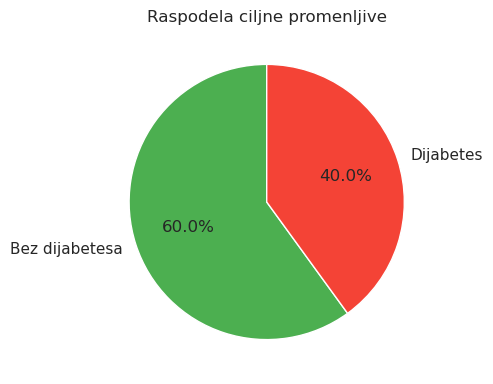

/tmp/ipykernel_9055/3142825281.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist() + binary_cols


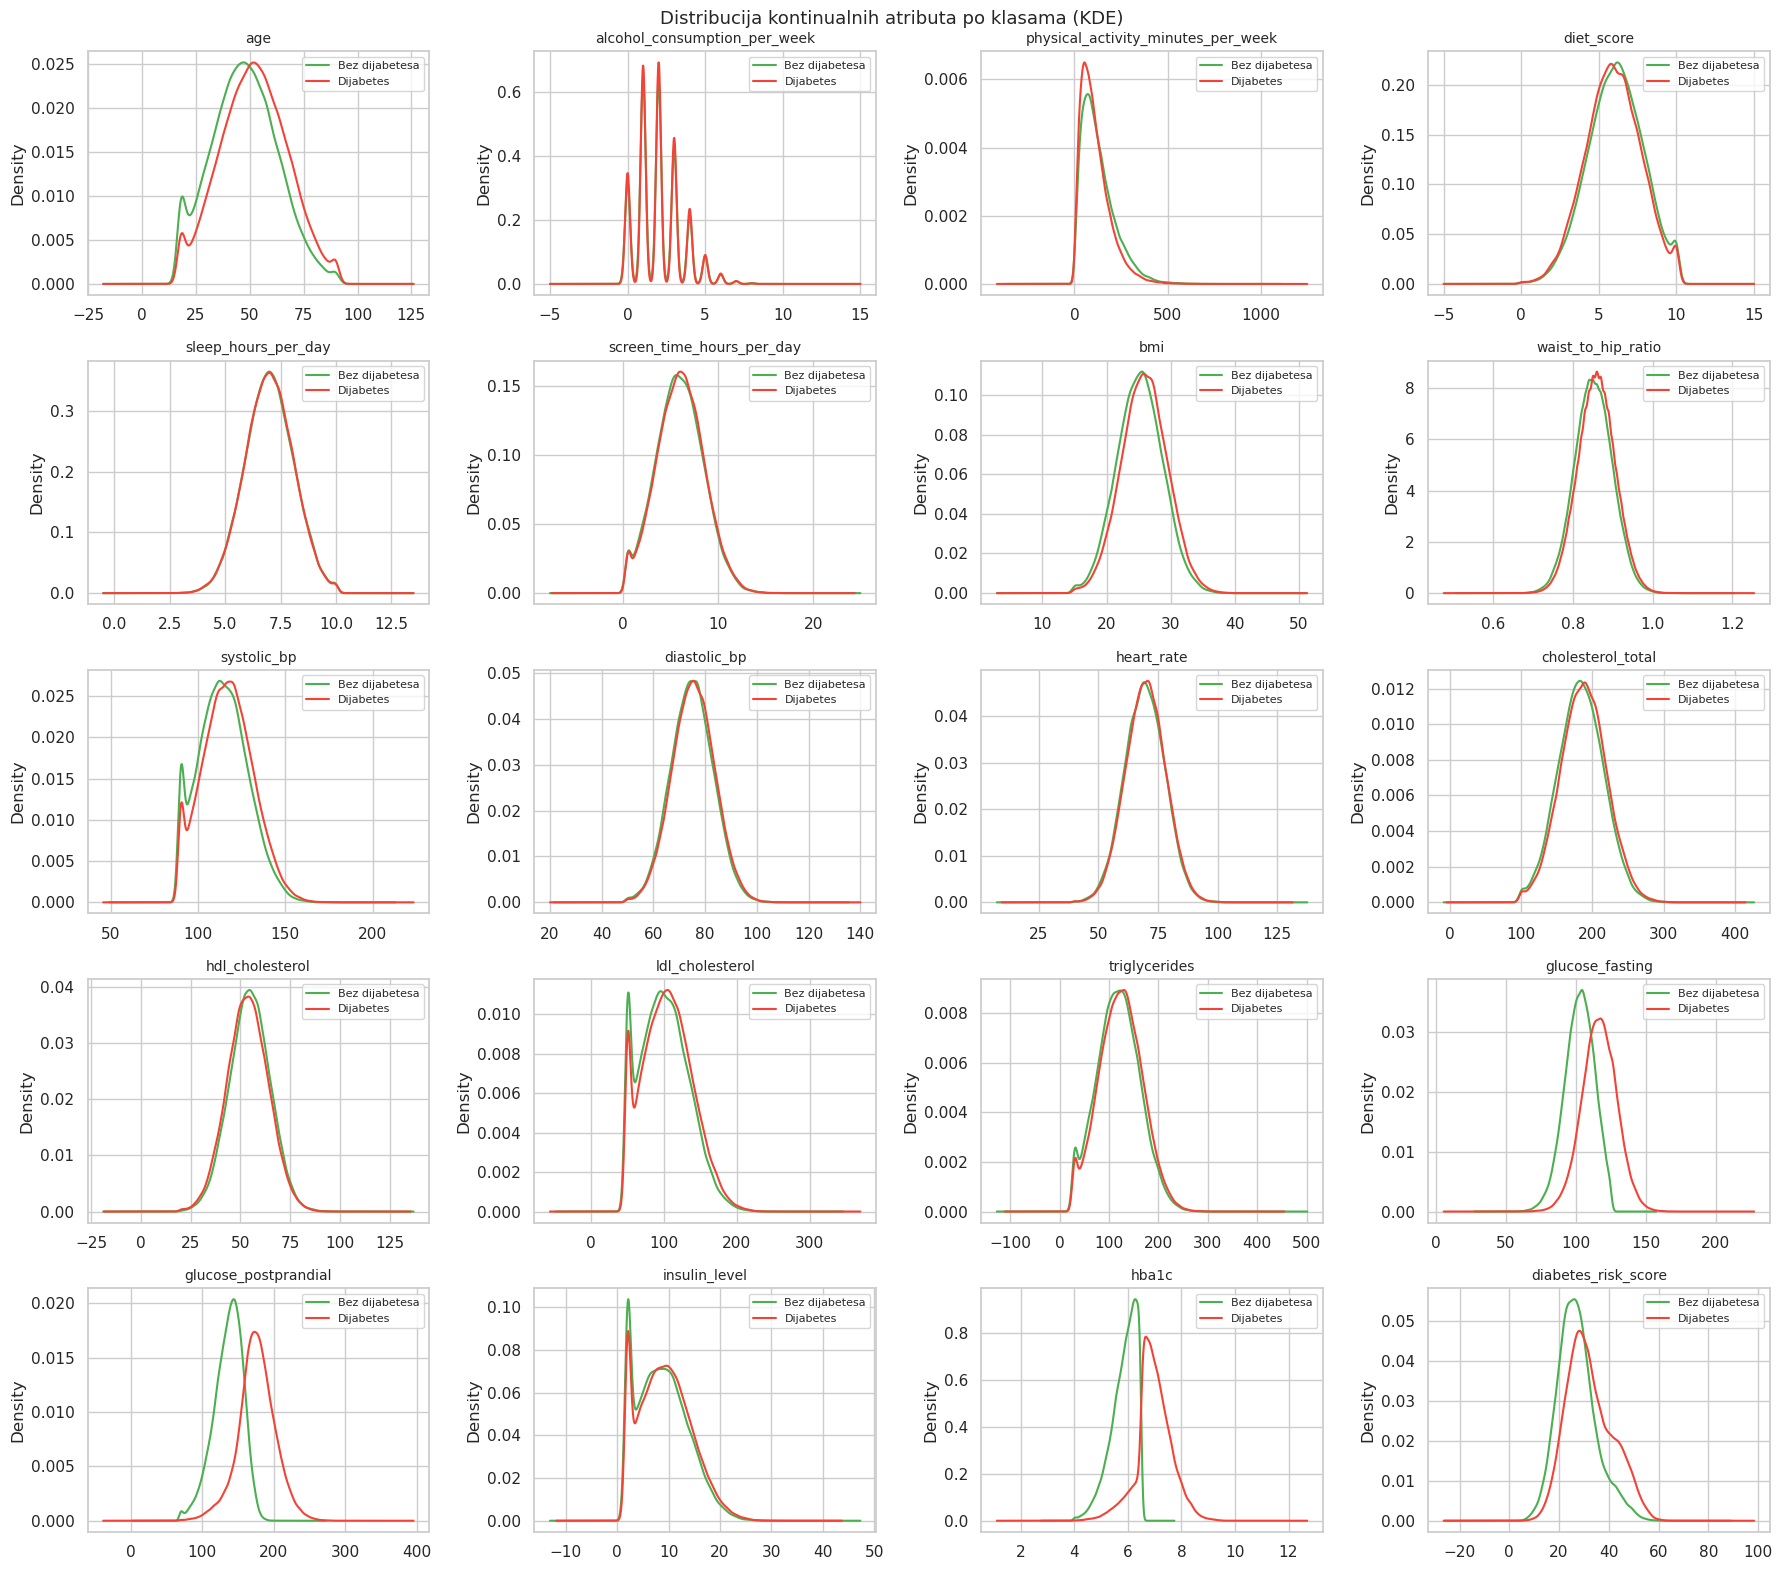

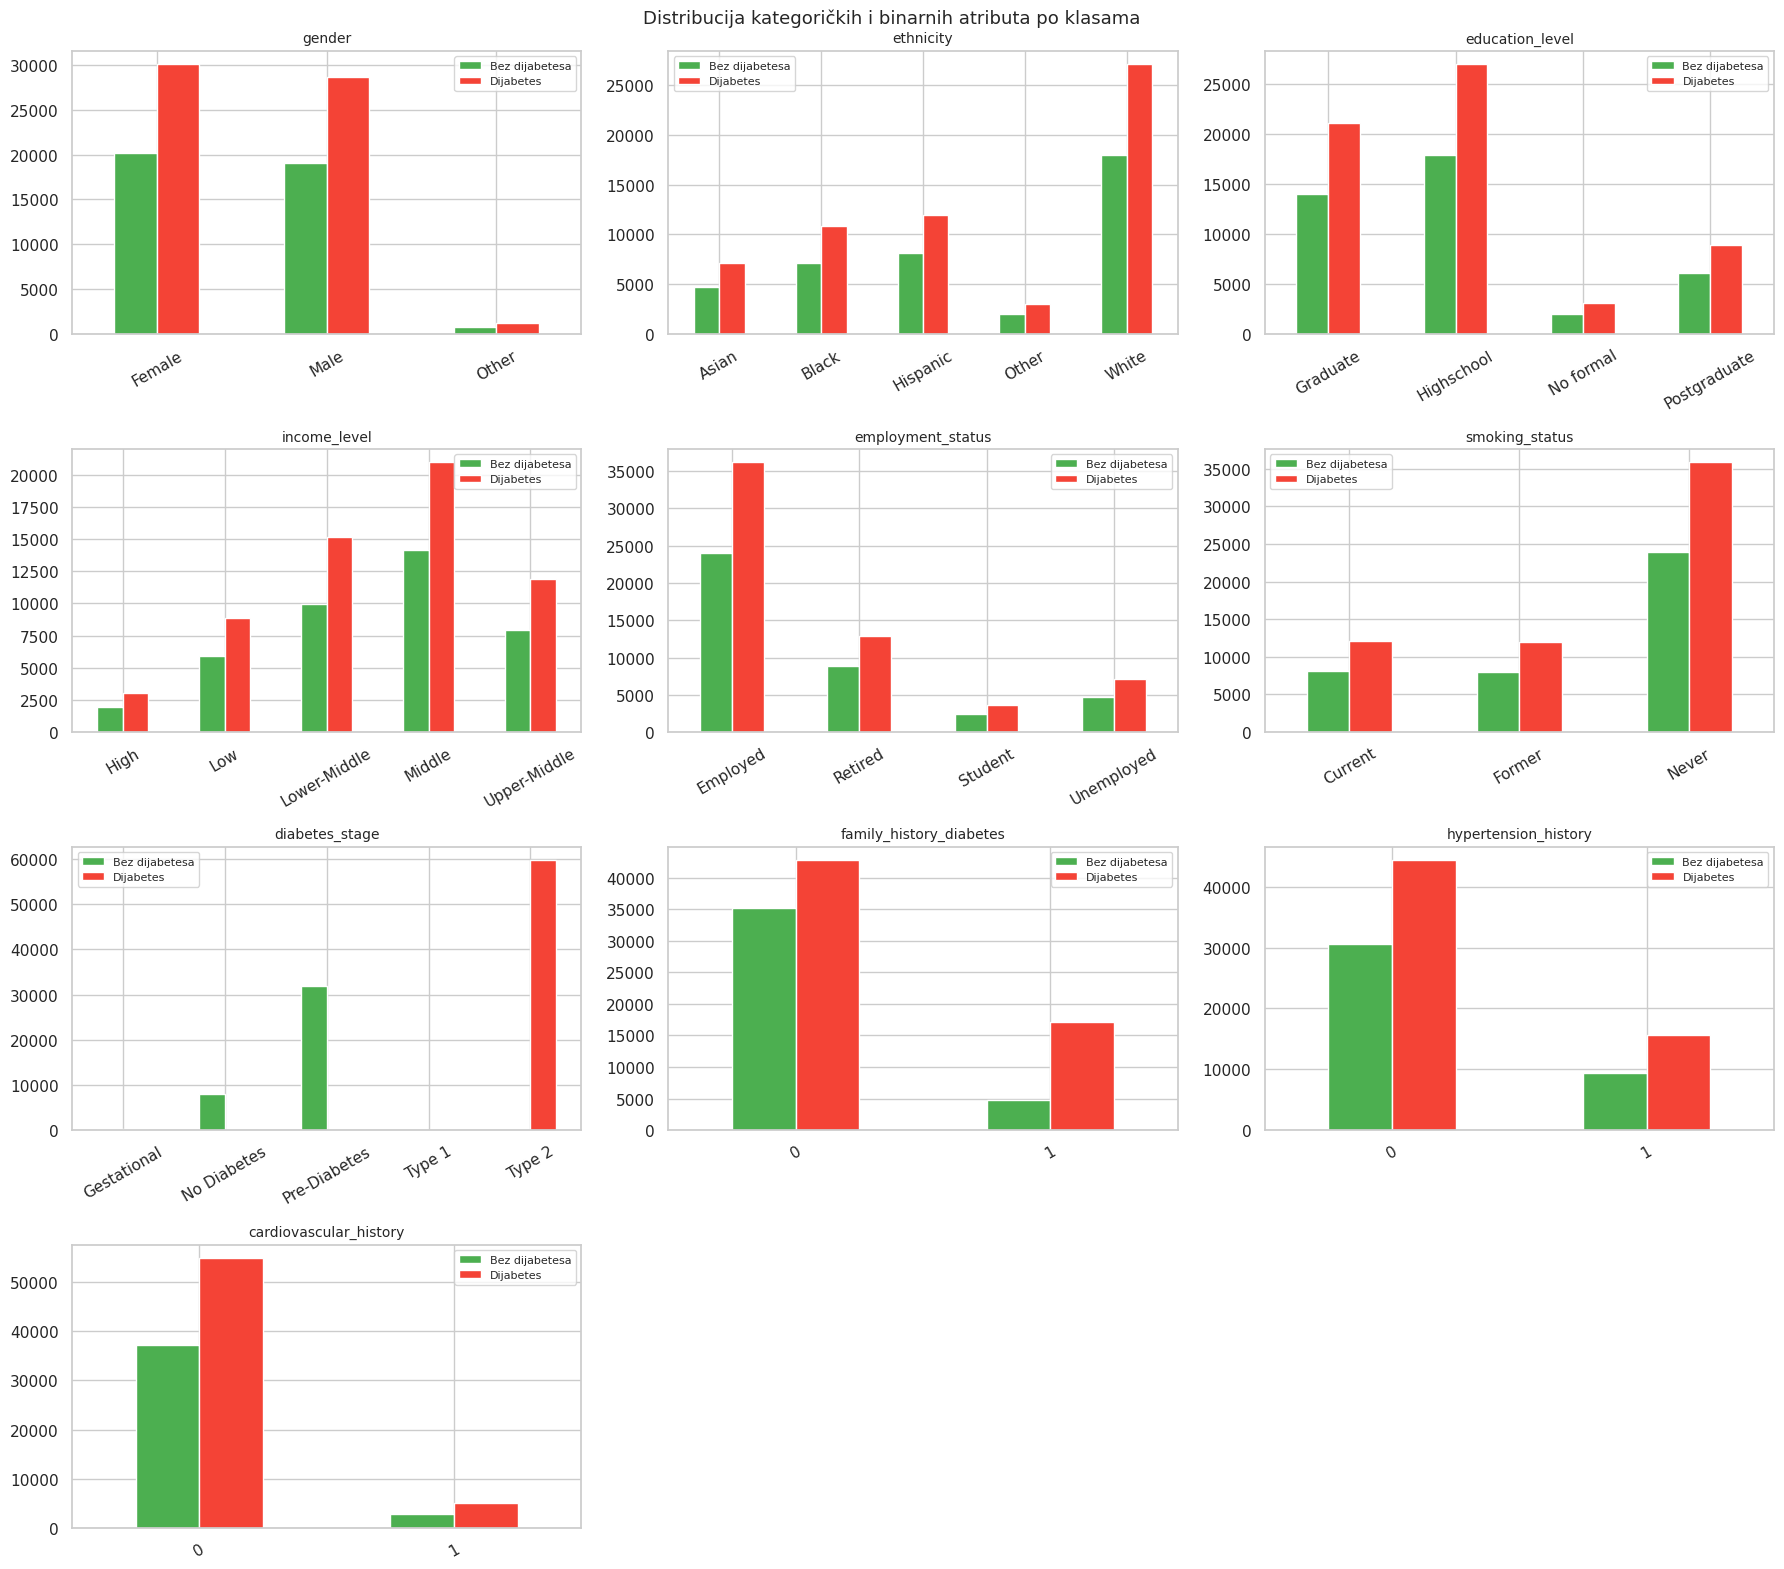

In [130]:
# Pie chart – raspodela ciljne promenljive
fig, ax = plt.subplots(figsize=(5, 5))
counts = df['diagnosed_diabetes'].value_counts()
ax.pie(counts, labels=['Bez dijabetesa', 'Dijabetes'], autopct='%1.1f%%',
       colors=['#4CAF50', '#F44336'], startangle=90)
ax.set_title('Raspodela ciljne promenljive')
plt.tight_layout()
plt.show()

# Binarni atributi su kategorički (0/1), ne kontinualni
binary_cols = ['family_history_diabetes', 'hypertension_history', 'cardiovascular_history']

# Kontinualni numerički atributi (bez binarnih i targeta)
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in binary_cols + ['diagnosed_diabetes']]

# Kategorički: string kolone + binarni atributi
cat_cols = df.select_dtypes(include=['object']).columns.tolist() + binary_cols

# KDE distribucija kontinualnih atributa po klasi
ncols = 4
nrows = int(np.ceil(len(num_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.2))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for cls, color, label in [(0, '#4CAF50', 'Bez dijabetesa'), (1, '#F44336', 'Dijabetes')]:
        df[df['diagnosed_diabetes'] == cls][col].plot(kind='kde', ax=axes[i], color=color, label=label)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribucija kontinualnih atributa po klasama (KDE)', fontsize=13)
plt.tight_layout()
plt.show()

# Bar chart kategoričkih i binarnih atributa po klasi
ncols_c = 3
nrows_c = int(np.ceil(len(cat_cols) / ncols_c))
fig, axes = plt.subplots(nrows_c, ncols_c, figsize=(18, nrows_c * 4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df.groupby([col, 'diagnosed_diabetes']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Bez dijabetesa', 'Dijabetes'], fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribucija kategoričkih i binarnih atributa po klasama', fontsize=13)
plt.tight_layout()
plt.show()

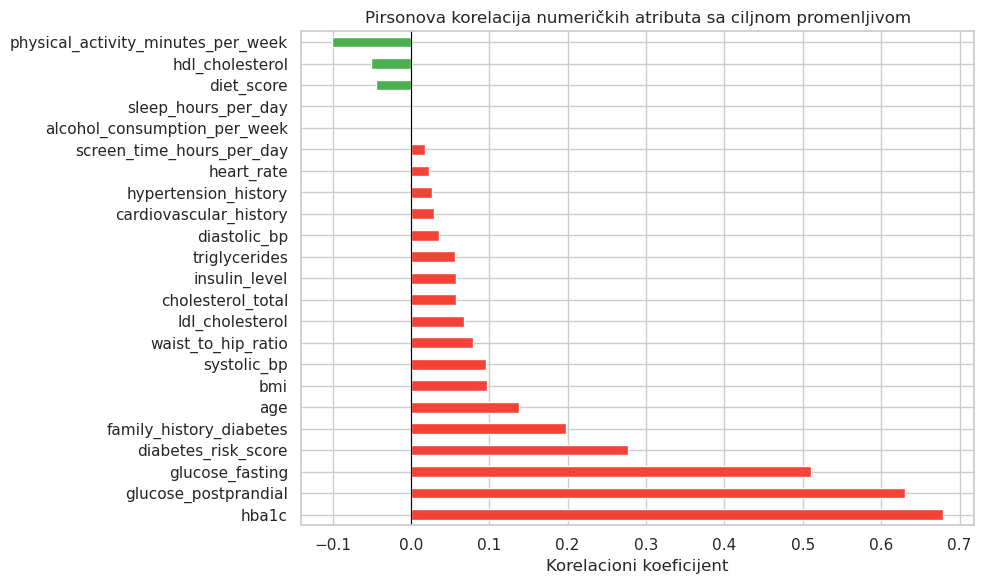

Top 5 pozitivno korelisanih: ['hba1c', 'glucose_postprandial', 'glucose_fasting', 'diabetes_risk_score', 'family_history_diabetes']
Top 5 negativno korelisanih: ['alcohol_consumption_per_week', 'sleep_hours_per_day', 'diet_score', 'hdl_cholesterol', 'physical_activity_minutes_per_week']


In [131]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('diagnosed_diabetes')

corr_with_target = df[numerical_cols].corrwith(df['diagnosed_diabetes']).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#F44336' if v > 0 else '#4CAF50' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pirsonova korelacija numeričkih atributa sa ciljnom promenljivom')
plt.xlabel('Korelacioni koeficijent')
plt.tight_layout()
plt.show()

print("Top 5 pozitivno korelisanih:", corr_with_target.head().index.tolist())
print("Top 5 negativno korelisanih:", corr_with_target.tail().index.tolist())

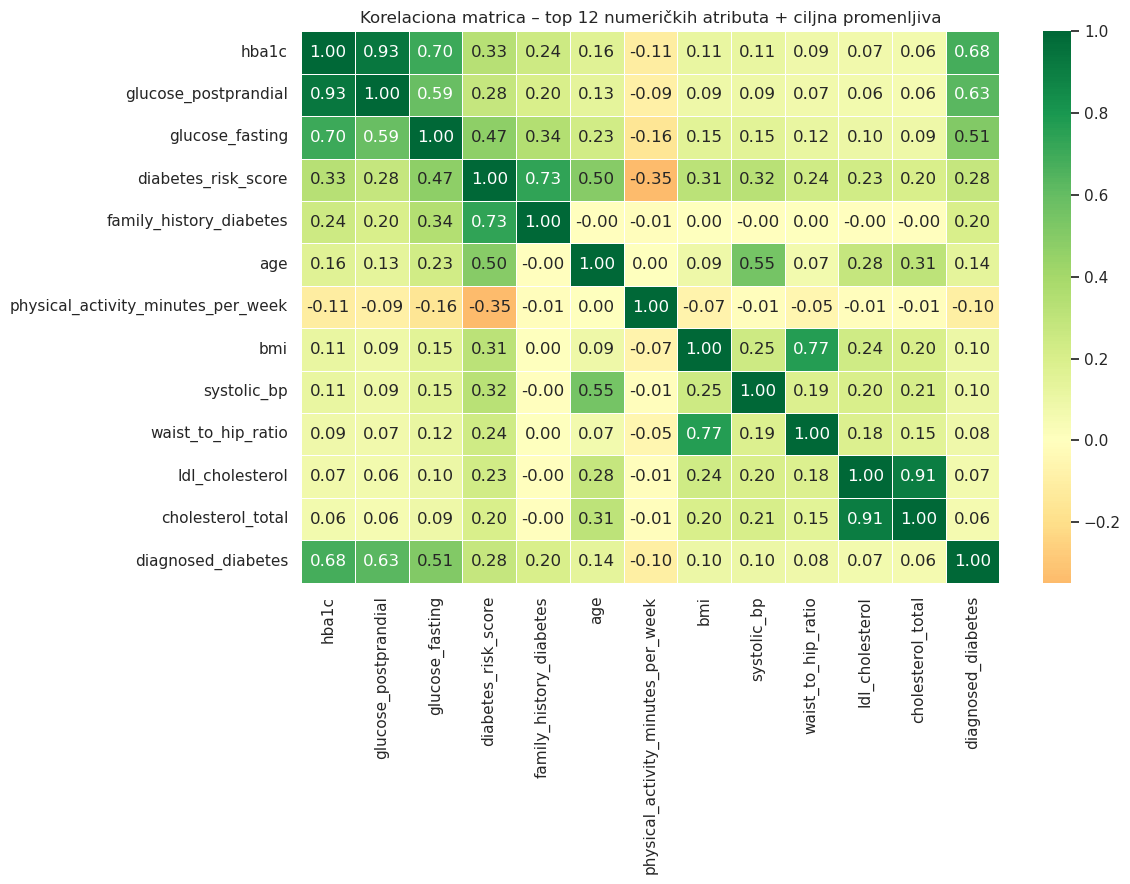

In [ ]:
top_features = corr_with_target.abs().nlargest(12).index.tolist() + ['diagnosed_diabetes']
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Korelaciona matrica – top 12 numeričkih atributa + ciljna promenljiva')
plt.tight_layout()
plt.show()

## 3. Predobrada podataka

In [133]:
# Uklanjanje diabetes_stage i diabetes_risk_score (data leakage)
df_clean = df.drop(columns=['diabetes_stage', 'diabetes_risk_score'])

# One-Hot Encoding za pol
df_clean = pd.get_dummies(df_clean, columns=['gender'], drop_first=True)

# Label-encode kategorickih feature-a
categorical_cols = ['ethnicity', 'education_level',
                    'income_level', 'employment_status', 'smoking_status']
le = LabelEncoder()
for col in categorical_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# Prediktori i target
X = df_clean.drop(columns=['diagnosed_diabetes'])
y = df_clean['diagnosed_diabetes']
feature_names = X.columns.tolist()
print(f"Features ({len(feature_names)}): {feature_names}")

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")

# StandardScaler 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
X_train_sc = pd.DataFrame(X_train_sc, columns=feature_names)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=feature_names)

# MinMaxScaler (nenegativne vrednosti potrebne za chi-squared)
mm_scaler = MinMaxScaler()
X_train_mm = pd.DataFrame(mm_scaler.fit_transform(X_train), columns=feature_names)
X_test_mm  = pd.DataFrame(mm_scaler.transform(X_test),      columns=feature_names)

print("\nPreprocessing complete.")

Features (29): ['age', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'gender_Male', 'gender_Other']

Train: (80000, 29), Test: (20000, 29)

Preprocessing complete.


In [134]:
results = []

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, n_features=None):
    start = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - start

    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None

    acc   = accuracy_score(y_te, y_pred)
    f1    = f1_score(y_te, y_pred)
    auc   = roc_auc_score(y_te, y_prob) if y_prob is not None else None
    n_feat = n_features if n_features is not None else X_tr.shape[1]
    algo  = type(model).__name__

    results.append({
        'Method':         name,
        'Algorithm':      algo,
        'N features':     n_feat,
        'Accuracy':       acc,
        'F1':             f1,
        'AUC-ROC':        auc,
        'Train time (s)': round(train_time, 3),
    })

    auc_str = f"{auc:.4f}" if auc is not None else "N/A"
    print(f"  [{algo}]  N={n_feat:2d}  Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_str}  Time={train_time:.3f}s")
    return model

N_SELECT = 10

## 4. Treniranje bez selekcije atributa

Pre primene selekcije atributa, treniramo modele na **svim atributima** kako bismo dobili referentne
vrednosti performansi sa kojima ćemo porediti rezultate selekcije.

In [135]:
print("BASELINE MODELS – all features (no selection)")

for model in [
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
]:
    evaluate_model("Baseline – all features", model, X_train_sc, X_test_sc, y_train, y_test)

BASELINE MODELS – all features (no selection)
  [LogisticRegression]  N=29  Acc=0.8606  F1=0.8851  AUC=0.9338  Time=0.120s
  [RandomForestClassifier]  N=29  Acc=0.9197  F1=0.9284  AUC=0.9415  Time=1.509s


## 5. Filter metode

Filter metode procenjuju svaki atribut nezavisno, bez treniranja modela.
Primenjuju se kao prethodni korak pre treniranja.

### 5.1 VarianceThreshold

Uklanja atribute čija je varijansa ispod zadatog praga.
Ne koristi ciljnu promenljivu – atributi sa malom varijabelnošću nemaju diskriminativnu moć.

FILTER METHOD 1: VarianceThreshold
Threshold: 0.1
Kept:    26 features
Removed: 3 features: ['cardiovascular_history', 'waist_to_hip_ratio', 'gender_Other']
  [LogisticRegression]  N=26  Acc=0.8606  F1=0.8851  AUC=0.9338  Time=0.071s
  [RandomForestClassifier]  N=26  Acc=0.9197  F1=0.9284  AUC=0.9407  Time=1.665s


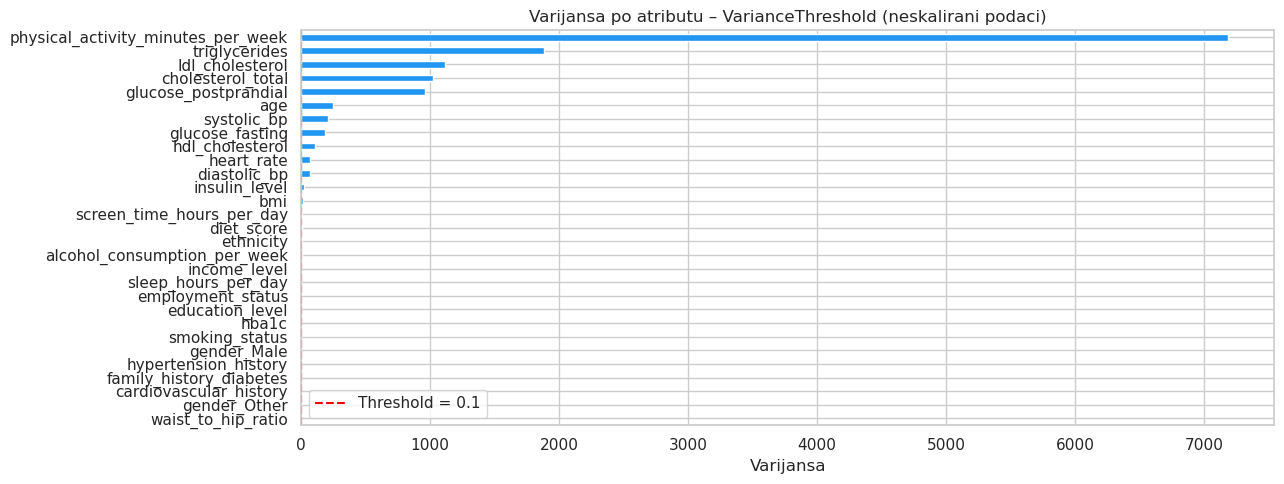

In [136]:
print("FILTER METHOD 1: VarianceThreshold")

# VarianceThreshold se mora fit-ovati na NESKALIRANIM podacima.
# StandardScaler normalizuje varijansu svake kolone na ~1, pa threshold nema efekta.
vt = VarianceThreshold(threshold=0.1)
vt.fit(X_train)  

selected_vt = [feature_names[i] for i in range(len(feature_names)) if vt.get_support()[i]]
removed_vt  = [feature_names[i] for i in range(len(feature_names)) if not vt.get_support()[i]]

print(f"Threshold: 0.1")
print(f"Kept:    {len(selected_vt)} features")
print(f"Removed: {len(removed_vt)} features: {removed_vt}")

# Primeni masku na skalirane podatke za trening modela
X_train_vt = X_train_sc[selected_vt]
X_test_vt  = X_test_sc[selected_vt]

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Filter – VarianceThreshold (threshold=0.1)",
        model, X_train_vt, X_test_vt, y_train, y_test,
        n_features=len(selected_vt))

# Varijanse na neskaliranim podacima
variances = pd.Series(vt.variances_, index=feature_names).sort_values()
plt.figure(figsize=(13, 5))
colors = ['#F44336' if v < 0.1 else '#2196F3' for v in variances]
variances.plot(kind='barh', color=colors)
plt.axvline(0.1, color='red', linestyle='--', label='Threshold = 0.1')
plt.title('Varijansa po atributu – VarianceThreshold (neskalirani podaci)')
plt.xlabel('Varijansa')
plt.legend()
plt.tight_layout()
plt.show()

### 5.2 ANOVA F-test

**ANOVA F-test** (`f_classif`): meri statističku razliku srednje vrednosti atributa između klasa.
Pretpostavlja normalnu distribuciju i linearne zavisnosti.

FILTER METHOD 2: ANOVA F-test
  [LogisticRegression]  N=10  Acc=0.8604  F1=0.8849  AUC=0.9338  Time=0.141s
  [RandomForestClassifier]  N=10  Acc=0.9198  F1=0.9284  AUC=0.9403  Time=1.055s
ANOVA selected: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'ldl_cholesterol', 'glucose_fasting', 'glucose_postprandial', 'hba1c']


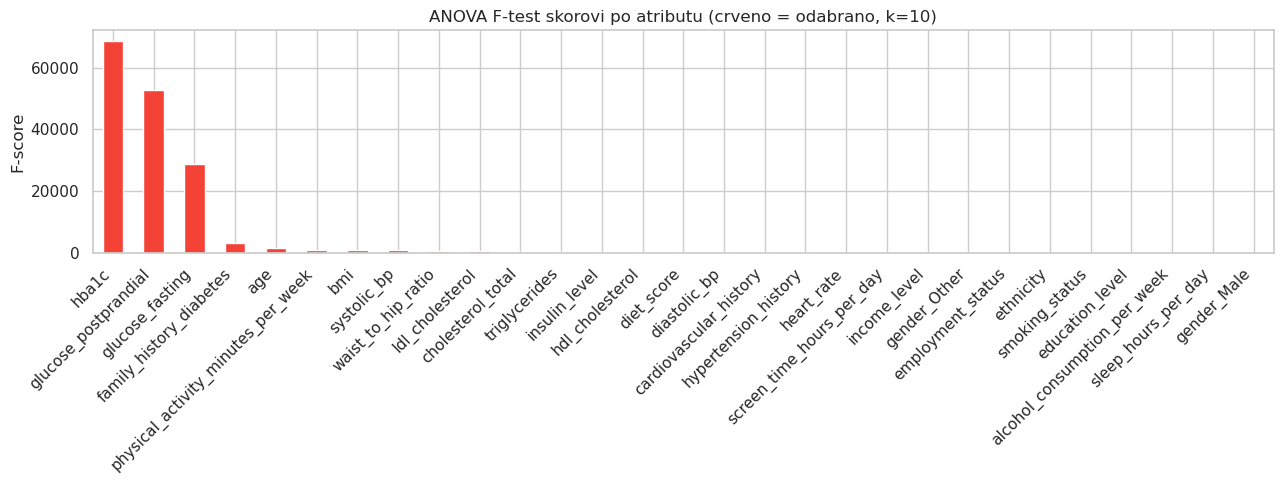

In [137]:
print("FILTER METHOD 2: ANOVA F-test")

sel_anova = SelectKBest(score_func=f_classif, k=N_SELECT)
X_train_anova = sel_anova.fit_transform(X_train_sc, y_train)
X_test_anova  = sel_anova.transform(X_test_sc)
selected_anova = [feature_names[i] for i in range(len(feature_names)) if sel_anova.get_support()[i]]

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Filter – ANOVA F-test (k={N_SELECT})",
        model, X_train_anova, X_test_anova, y_train, y_test, n_features=N_SELECT)

print(f"ANOVA selected: {selected_anova}")

f_scores = pd.Series(sel_anova.scores_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(13, 5))
colors = ['#F44336' if f in selected_anova else '#9E9E9E' for f in f_scores.index]
f_scores.plot(kind='bar', color=colors)
plt.title(f'ANOVA F-test skorovi po atributu (crveno = odabrano, k={N_SELECT})')
plt.ylabel('F-score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Mutual Information

**Mutual Information** (`mutual_info_classif`): meri koliko informacije atribut pruža o ciljnoj
promenljivoj. Detektuje i nelinearne zavisnosti, ali je statistički nestabilnija.

FILTER METHOD 3: Mutual Information
  [LogisticRegression]  N=10  Acc=0.8600  F1=0.8847  AUC=0.9336  Time=0.090s
  [RandomForestClassifier]  N=10  Acc=0.9198  F1=0.9284  AUC=0.9370  Time=0.784s
MI selected: ['age', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'ldl_cholesterol', 'glucose_fasting', 'glucose_postprandial', 'hba1c', 'gender_Male']


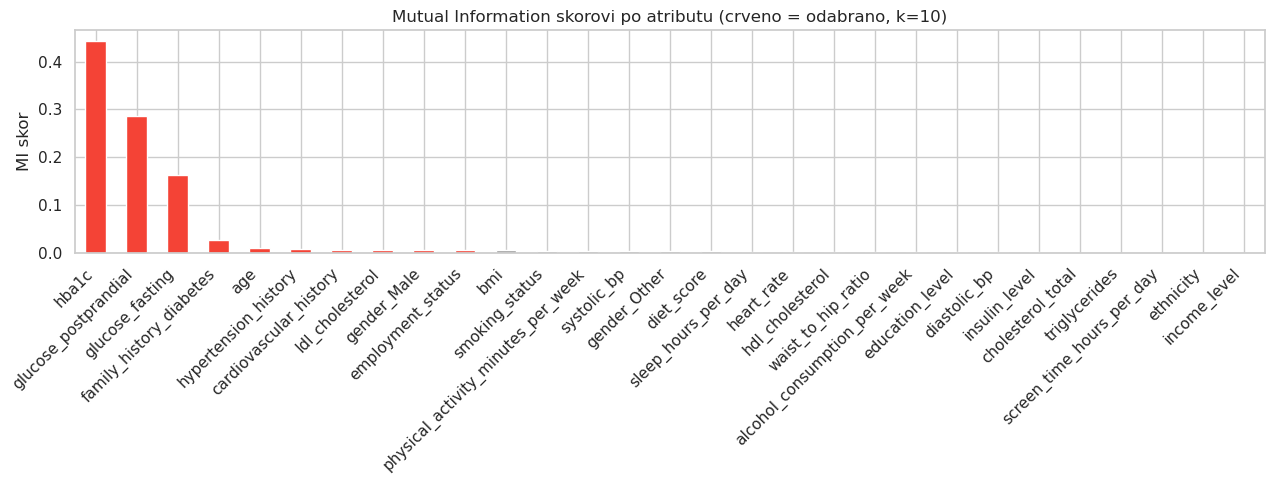

In [138]:
print("FILTER METHOD 3: Mutual Information")

sel_mi = SelectKBest(score_func=mutual_info_classif, k=N_SELECT)
X_train_mi = sel_mi.fit_transform(X_train_sc, y_train)
X_test_mi  = sel_mi.transform(X_test_sc)
selected_mi = [feature_names[i] for i in range(len(feature_names)) if sel_mi.get_support()[i]]

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Filter – Mutual Information (k={N_SELECT})",
        model, X_train_mi, X_test_mi, y_train, y_test, n_features=N_SELECT)

print(f"MI selected: {selected_mi}")

mi_scores = pd.Series(sel_mi.scores_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(13, 5))
colors = ['#F44336' if f in selected_mi else '#9E9E9E' for f in mi_scores.index]
mi_scores.plot(kind='bar', color=colors)
plt.title(f'Mutual Information skorovi po atributu (crveno = odabrano, k={N_SELECT})')
plt.ylabel('MI skor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.4 Chi-squared test

Chi-squared test meri statističku zavisnost između kategoričkih atributa i ciljne promenljive.
**Uslov:** vrednosti atributa moraju biti nenegativne → koristimo `MinMaxScaler` umesto `StandardScaler`.

FILTER METHOD 4: Chi-squared test
  [LogisticRegression]  N=10  Acc=0.8599  F1=0.8847  AUC=0.9336  Time=0.373s
  [RandomForestClassifier]  N=10  Acc=0.9195  F1=0.9282  AUC=0.9398  Time=0.940s

Chi2 selected: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'systolic_bp', 'glucose_fasting', 'glucose_postprandial', 'hba1c']


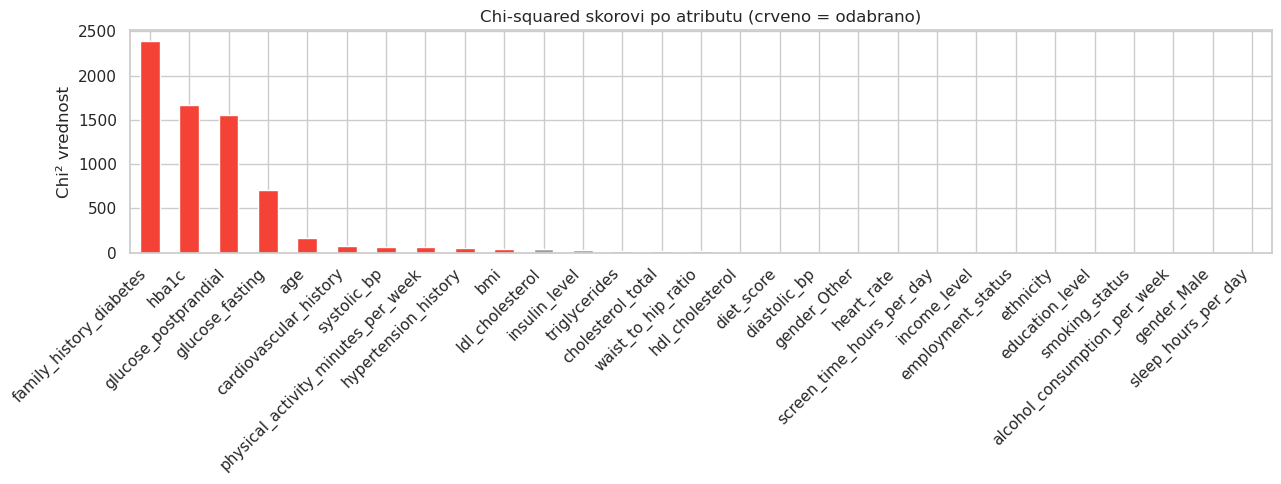

In [139]:
print("FILTER METHOD 4: Chi-squared test")

# MinMaxScaled data (non-negative values required)
sel_chi2 = SelectKBest(score_func=chi2, k=N_SELECT)
X_train_chi2 = sel_chi2.fit_transform(X_train_mm, y_train)
X_test_chi2  = sel_chi2.transform(X_test_mm)
selected_chi2 = [feature_names[i] for i in range(len(feature_names)) if sel_chi2.get_support()[i]]

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Filter – Chi-squared (k={N_SELECT})",
        model, X_train_chi2, X_test_chi2, y_train, y_test, n_features=N_SELECT)

print(f"\nChi2 selected: {selected_chi2}")

# Chi2 score chart
chi2_scores = pd.Series(sel_chi2.scores_, index=feature_names).sort_values(ascending=False)
plt.figure(figsize=(13, 5))
colors = ['#F44336' if f in selected_chi2 else '#9E9E9E' for f in chi2_scores.index]
chi2_scores.plot(kind='bar', color=colors)
plt.title('Chi-squared skorovi po atributu (crveno = odabrano)')
plt.ylabel('Chi² vrednost')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 6. Wrapper metode

Wrapper metode koriste sam model mašinskog učenja kao funkciju za ocenjivanje podskupova atributa.
Generalno daju bolje rezultate od filter metoda, ali su računarski skuplje.

### 6.1 Rekurzivna eliminacija atributa (RFE)

RFE počinje od svih atributa i iterativno eliminiše atribut sa najnižim koeficijentom/važnošću.

WRAPPER METHOD 1: RFE (Recursive Feature Elimination)
RFE fit time: 2.09s
Selected: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'glucose_fasting', 'glucose_postprandial', 'hba1c']
  [LogisticRegression]  N=10  Acc=0.8609  F1=0.8853  AUC=0.9337  Time=0.093s
  [RandomForestClassifier]  N=10  Acc=0.9197  F1=0.9284  AUC=0.9392  Time=1.254s


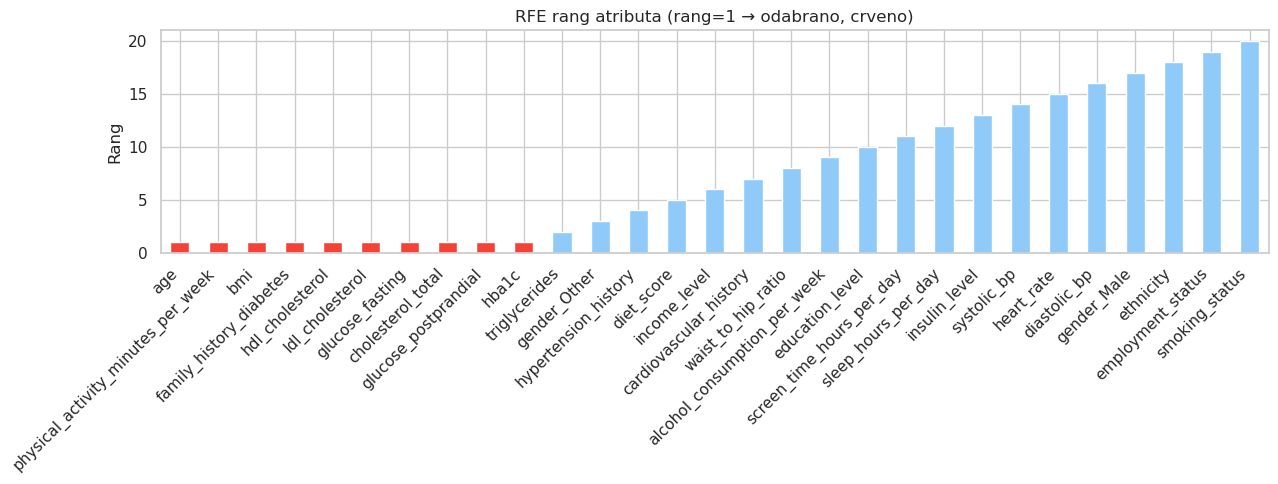

In [140]:
print("WRAPPER METHOD 1: RFE (Recursive Feature Elimination)")

rfe = RFE(estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
          n_features_to_select=N_SELECT, step=1)

t0 = time.perf_counter()
rfe.fit(X_train_sc, y_train)
rfe_fit_time = time.perf_counter() - t0

X_train_rfe = rfe.transform(X_train_sc)
X_test_rfe  = rfe.transform(X_test_sc)
selected_rfe = [feature_names[i] for i in range(len(feature_names)) if rfe.get_support()[i]]

print(f"RFE fit time: {rfe_fit_time:.2f}s")
print(f"Selected: {selected_rfe}")

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Wrapper – RFE (k={N_SELECT})",
        model, X_train_rfe, X_test_rfe, y_train, y_test, n_features=N_SELECT)

# Feature rankings
ranks = pd.Series(rfe.ranking_, index=feature_names).sort_values()
plt.figure(figsize=(13, 5))
colors = ['#F44336' if r == 1 else '#90CAF9' for r in ranks.values]
ranks.plot(kind='bar', color=colors)
plt.title('RFE rang atributa (rang=1 → odabrano, crveno)')
plt.ylabel('Rang')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 6.2 RFECV – automatski odabir optimalnog broja atributa

`RFECV` kombinuje RFE sa unakrsnom validacijom i automatski određuje optimalan broj atributa
bez potrebe za ručnim postavljanjem `k`.

WRAPPER METHOD 2: RFECV (auto k selection via cross-validation)
RFECV fit time: 7.46s
Optimal n_features: 8
Selected: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'cholesterol_total', 'ldl_cholesterol', 'glucose_fasting', 'hba1c']
  [LogisticRegression]  N= 8  Acc=0.8606  F1=0.8851  AUC=0.9337  Time=0.098s
  [RandomForestClassifier]  N= 8  Acc=0.9194  F1=0.9281  AUC=0.9391  Time=0.879s


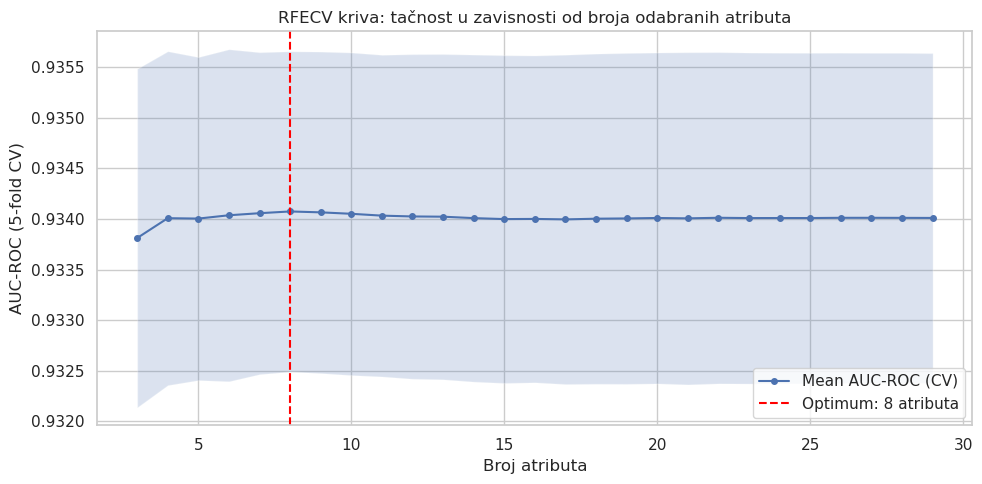

In [141]:
print("WRAPPER METHOD 2: RFECV (auto k selection via cross-validation)")

rfecv = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    min_features_to_select=3,
    n_jobs=-1
)
t0 = time.perf_counter()
rfecv.fit(X_train_sc, y_train)
rfecv_time = time.perf_counter() - t0

selected_rfecv = [feature_names[i] for i in range(len(feature_names)) if rfecv.get_support()[i]]
print(f"RFECV fit time: {rfecv_time:.2f}s")
print(f"Optimal n_features: {rfecv.n_features_}")
print(f"Selected: {selected_rfecv}")

X_train_rfecv = rfecv.transform(X_train_sc)
X_test_rfecv  = rfecv.transform(X_test_sc)
for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Wrapper – RFECV (k={rfecv.n_features_}, auto)",
        model, X_train_rfecv, X_test_rfecv, y_train, y_test, n_features=rfecv.n_features_)

# RFECV curve
cv_results = rfecv.cv_results_
mean_scores = cv_results['mean_test_score']
std_scores  = cv_results['std_test_score']
n_range = range(rfecv.min_features_to_select,
                rfecv.min_features_to_select + len(mean_scores))

plt.figure(figsize=(10, 5))
plt.plot(n_range, mean_scores, 'b-o', markersize=4, label='Mean AUC-ROC (CV)')
plt.fill_between(n_range,
                 mean_scores - std_scores,
                 mean_scores + std_scores,
                 alpha=0.2)
plt.axvline(rfecv.n_features_, color='red', linestyle='--',
            label=f'Optimum: {rfecv.n_features_} atributa')
plt.xlabel('Broj atributa')
plt.ylabel('AUC-ROC (5-fold CV)')
plt.title('RFECV kriva: tačnost u zavisnosti od broja odabranih atributa')
plt.legend()
plt.tight_layout()
plt.show()

### 6.3 Sekvencijalni odabir atributa (SFS – forward i backward)

- **Forward selection**: počinje od praznog skupa, dodaje atribut po atribut
- **Backward elimination**: počinje od svih atributa, eliminiše jedan po jedan

In [142]:
print("WRAPPER METHOD 3: Sequential Feature Selection (SFS)")

lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

# Forward SFS
sfs_fwd = SequentialFeatureSelector(lr, n_features_to_select=N_SELECT,
                                     direction='forward', cv=3, n_jobs=-1)
t0 = time.perf_counter()
sfs_fwd.fit(X_train_sc, y_train)
print(f"Forward SFS fit time: {time.perf_counter()-t0:.2f}s")
selected_fwd = [feature_names[i] for i in range(len(feature_names)) if sfs_fwd.get_support()[i]]
print(f"Forward selected: {selected_fwd}")

X_train_fwd = sfs_fwd.transform(X_train_sc)
X_test_fwd  = sfs_fwd.transform(X_test_sc)
for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(f"Wrapper – SFS Forward (k={N_SELECT})",
                   model, X_train_fwd, X_test_fwd, y_train, y_test, n_features=N_SELECT)

# Backward SFS
sfs_bwd = SequentialFeatureSelector(lr, n_features_to_select=N_SELECT,
                                      direction='backward', cv=3, n_jobs=-1)
t0 = time.perf_counter()
sfs_bwd.fit(X_train_sc, y_train)
print(f"\nBackward SFS fit time: {time.perf_counter()-t0:.2f}s")
selected_bwd = [feature_names[i] for i in range(len(feature_names)) if sfs_bwd.get_support()[i]]
print(f"Backward selected: {selected_bwd}")

X_train_bwd = sfs_bwd.transform(X_train_sc)
X_test_bwd  = sfs_bwd.transform(X_test_sc)
for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(f"Wrapper – SFS Backward (k={N_SELECT})",
                   model, X_train_bwd, X_test_bwd, y_train, y_test, n_features=N_SELECT)

common = sorted(set(selected_fwd) & set(selected_bwd))
print(f"\nZajednički atributi (forward ∩ backward): {common}")

WRAPPER METHOD 3: Sequential Feature Selection (SFS)
Forward SFS fit time: 39.78s
Forward selected: ['age', 'education_level', 'employment_status', 'family_history_diabetes', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'ldl_cholesterol', 'glucose_fasting', 'hba1c']
  [LogisticRegression]  N=10  Acc=0.8603  F1=0.8849  AUC=0.9337  Time=0.046s
  [RandomForestClassifier]  N=10  Acc=0.9195  F1=0.9282  AUC=0.9390  Time=0.797s

Backward SFS fit time: 76.85s
Backward selected: ['age', 'income_level', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'hypertension_history', 'bmi', 'cholesterol_total', 'ldl_cholesterol', 'glucose_fasting', 'hba1c']
  [LogisticRegression]  N=10  Acc=0.8609  F1=0.8853  AUC=0.9337  Time=0.079s
  [RandomForestClassifier]  N=10  Acc=0.9197  F1=0.9283  AUC=0.9403  Time=0.925s

Zajednički atributi (forward ∩ backward): ['age', 'bmi', 'family_history_diabetes', 'glucose_fasting', 'hba1c', 'ldl_cholesterol']


## 7. Embedded metode

Embedded metode integrišu selekciju atributa direktno u proces treniranja modela.
Efikasnije su od wrapper metoda jer ne zahtevaju višestruko treniranje.

### 7.1 LASSO regularizacija (L1)

L1 regularizacija "gura" koeficijente prema nuli – atributi čiji koeficijenti postanu tačno nula
efektivno su eliminirani. Parametar $\alpha$ se bira automatski putem `LassoCV`.

EMBEDDED METHOD 1: LASSO (L1 regularization)


/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove re

LASSO CV fit time: 5.34s
Best C: 0.0034  → α ≈ 297.6351
Active features: 8
Selected: ['age', 'physical_activity_minutes_per_week', 'family_history_diabetes', 'bmi', 'hdl_cholesterol', 'ldl_cholesterol', 'glucose_fasting', 'hba1c']
  [LogisticRegression]  N=10  Acc=0.8608  F1=0.8853  AUC=0.9338  Time=0.065s
  [RandomForestClassifier]  N=10  Acc=0.9196  F1=0.9283  AUC=0.9396  Time=0.964s


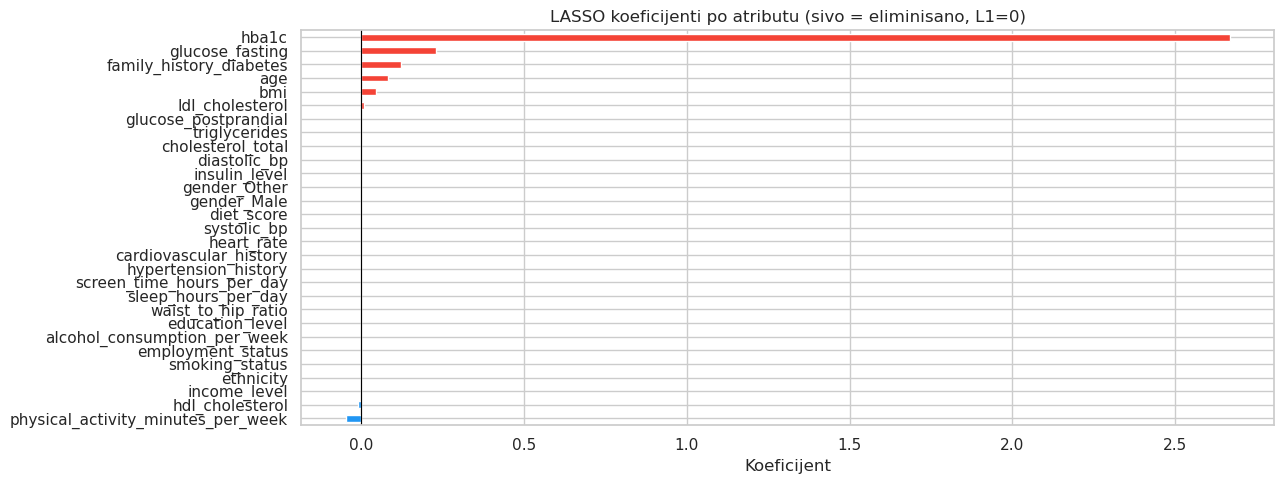

In [143]:
print("EMBEDDED METHOD 1: LASSO (L1 regularization)")

lasso_lr = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 20),
    cv=5,
    penalty='l1',
    solver='saga',
    max_iter=3000,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
t0 = time.perf_counter()
lasso_lr.fit(X_train_sc, y_train)
lasso_fit_time = time.perf_counter() - t0

coef = lasso_lr.coef_[0]
active_mask = np.abs(coef) > 1e-6
selected_lasso = [feature_names[i] for i in range(len(feature_names)) if active_mask[i]]

print(f"LASSO CV fit time: {lasso_fit_time:.2f}s")
print(f"Best C: {lasso_lr.C_[0]:.4f}  → α ≈ {1/lasso_lr.C_[0]:.4f}")
print(f"Active features: {len(selected_lasso)}")
print(f"Selected: {selected_lasso}")

# Select top N_SELECT features by absolute coefficient value
coef_abs = pd.Series(np.abs(coef), index=feature_names)
selected_lasso_k = coef_abs.nlargest(N_SELECT).index.tolist()

X_train_lasso = X_train_sc[selected_lasso_k]
X_test_lasso  = X_test_sc[selected_lasso_k]

for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Embedded – LASSO L1 (top {N_SELECT})",
        model, X_train_lasso, X_test_lasso, y_train, y_test,
        n_features=N_SELECT)

# Coefficient chart
coef_series = pd.Series(coef, index=feature_names).sort_values()
colors = ['#F44336' if v > 0 else '#2196F3' for v in coef_series]
zero_mask = coef_series.abs() <= 1e-6
plt.figure(figsize=(13, 5))
coef_series.plot(kind='barh', color=['#9E9E9E' if z else c
                                      for z, c in zip(zero_mask, colors)])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('LASSO koeficijenti po atributu (sivo = eliminisano, L1=0)')
plt.xlabel('Koeficijent')
plt.tight_layout()
plt.show()

### 7.2 Važnost atributa iz Random Forest-a

Random Forest nativno izračunava `feature_importances_` – zbir smanjenja Gini indeksa
za svaki atribut, ponderisan brojem uzoraka koji prolaze kroz te čvorove.
`SelectFromModel` bira atribute čija je važnost iznad srednje vrednosti (ili `max_features=k`).

EMBEDDED METHOD 2: Random Forest Feature Importance
RF fit time: 2.93s
Top 10 by RF importance: ['hba1c', 'glucose_postprandial', 'glucose_fasting', 'physical_activity_minutes_per_week', 'age', 'bmi', 'triglycerides', 'insulin_level', 'screen_time_hours_per_day', 'cholesterol_total']
  [LogisticRegression]  N=10  Acc=0.8586  F1=0.8834  AUC=0.9335  Time=0.112s
  [RandomForestClassifier]  N=10  Acc=0.9200  F1=0.9285  AUC=0.9361  Time=1.315s


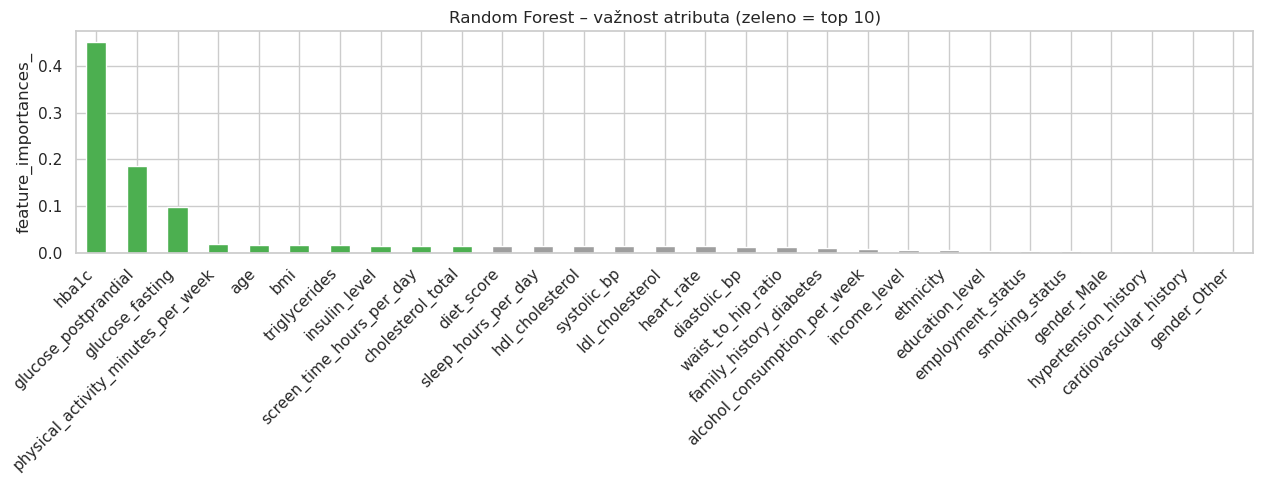

In [144]:
print("EMBEDDED METHOD 2: Random Forest Feature Importance")

rf_emb = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
t0 = time.perf_counter()
rf_emb.fit(X_train_sc, y_train)
rf_fit_time = time.perf_counter() - t0
print(f"RF fit time: {rf_fit_time:.2f}s")

importances = pd.Series(rf_emb.feature_importances_, index=feature_names).sort_values(ascending=False)
top_k_rf = importances.head(N_SELECT).index.tolist()
print(f"Top {N_SELECT} by RF importance: {top_k_rf}")

X_train_rf_emb = X_train_sc[top_k_rf]
X_test_rf_emb  = X_test_sc[top_k_rf]
for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Embedded – RF Importance (k={N_SELECT})",
        model, X_train_rf_emb, X_test_rf_emb, y_train, y_test, n_features=N_SELECT)

fig, ax = plt.subplots(figsize=(13, 5))
colors = ['#4CAF50' if f in top_k_rf else '#9E9E9E' for f in importances.index]
importances.plot(kind='bar', ax=ax, color=colors)
ax.set_title(f'Random Forest – važnost atributa (zeleno = top {N_SELECT})')
ax.set_ylabel('feature_importances_')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 7.3 Permutaciona važnost atributa

Permutaciona važnost je **model-agnostička** tehnika koja se može primeniti na bilo koji trenirani model.
Algoritam: nasumično meša vrednosti jednog atributa i meri pad performanse modela.
Atributi čije mešanje više kvari model su važniji.

Ova metoda ne pati od pristranosti prema atributima sa mnogo vrednosti grananja
(za razliku od `feature_importances_` iz stabala).

EMBEDDED METHOD 3: Permutation Feature Importance


/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/nemanja/miniconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: User

Top 10 by permutation importance: ['hba1c', 'glucose_fasting', 'family_history_diabetes', 'glucose_postprandial', 'age', 'bmi', 'cholesterol_total', 'ldl_cholesterol', 'waist_to_hip_ratio', 'physical_activity_minutes_per_week']
  [LogisticRegression]  N=10  Acc=0.8605  F1=0.8850  AUC=0.9337  Time=0.108s
  [RandomForestClassifier]  N=10  Acc=0.9198  F1=0.9285  AUC=0.9402  Time=1.347s


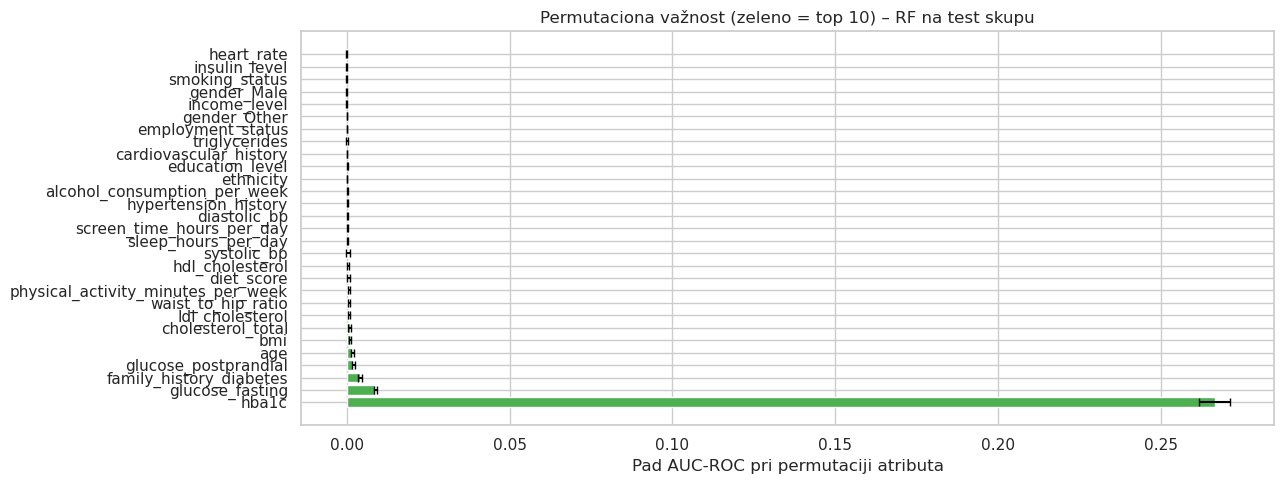

In [145]:
print("EMBEDDED METHOD 3: Permutation Feature Importance")

# Use pre-trained RF
perm = permutation_importance(
    rf_emb,
    X_test_sc.values,
    y_test.values,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring='roc_auc',
    n_jobs=-1
)

perm_mean = pd.Series(perm.importances_mean, index=feature_names).sort_values(ascending=False)
perm_std  = pd.Series(perm.importances_std,  index=feature_names).loc[perm_mean.index]
top_k_perm = perm_mean.head(N_SELECT).index.tolist()
print(f"Top {N_SELECT} by permutation importance: {top_k_perm}")

X_train_perm = X_train_sc[top_k_perm]
X_test_perm  = X_test_sc[top_k_perm]
for model in [LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
              RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)]:
    evaluate_model(
        f"Embedded – Permutation Importance (k={N_SELECT})",
        model, X_train_perm, X_test_perm, y_train, y_test, n_features=N_SELECT)

# Permutation importance chart with error bars
fig, ax = plt.subplots(figsize=(13, 5))
y_pos = np.arange(len(perm_mean))
colors = ['#4CAF50' if f in top_k_perm else '#9E9E9E' for f in perm_mean.index]
ax.barh(y_pos, perm_mean.values, xerr=perm_std.values,
        color=colors, align='center', ecolor='black', capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(perm_mean.index)
ax.set_xlabel('Pad AUC-ROC pri permutaciji atributa')
ax.set_title(f'Permutaciona važnost (zeleno = top {N_SELECT}) – RF na test skupu')
plt.tight_layout()
plt.show()

## 8. Poređenje svih metoda

U ovom odeljku prikazujemo sistematsko poređenje svih prikazanih metoda selekcije atributa
po sledećim kriterijumima: broj odabranih atributa, tačnost (Accuracy), F1 skor, AUC-ROC i vreme treniranja.

In [146]:
df_res = pd.DataFrame(results)

df_lr = df_res[df_res['Algorithm'] == 'LogisticRegression'].copy().reset_index(drop=True)
df_rf = df_res[df_res['Algorithm'] == 'RandomForestClassifier'].copy().reset_index(drop=True)

print("=" * 75)
print("LOGISTIC REGRESSION")
print("=" * 75)
print(df_lr[['Method', 'N features', 'Accuracy', 'F1', 'AUC-ROC', 'Train time (s)']].to_string(index=False))

print("\n" + "=" * 75)
print("RANDOM FOREST")
print("=" * 75)
print(df_rf[['Method', 'N features', 'Accuracy', 'F1', 'AUC-ROC', 'Train time (s)']].to_string(index=False))

for label, df_algo in [('LR', df_lr), ('RF', df_rf)]:
    sel = df_algo[~df_algo['Method'].str.startswith('Baseline')]
    best_row = sel.loc[sel['AUC-ROC'].idxmax()]
    print(f"\n[{label}] Najbolja metoda (AUC-ROC): {best_row['Method']} → {best_row['AUC-ROC']:.4f}")

LOGISTIC REGRESSION
                                    Method  N features  Accuracy       F1  AUC-ROC  Train time (s)
                   Baseline – all features          29   0.86055 0.885108 0.933766           0.120
Filter – VarianceThreshold (threshold=0.1)          26   0.86060 0.885126 0.933751           0.071
              Filter – ANOVA F-test (k=10)          10   0.86040 0.884932 0.933751           0.141
        Filter – Mutual Information (k=10)          10   0.86000 0.884650 0.933614           0.090
               Filter – Chi-squared (k=10)          10   0.85995 0.884652 0.933600           0.373
                      Wrapper – RFE (k=10)          10   0.86085 0.885327 0.933732           0.093
               Wrapper – RFECV (k=8, auto)           8   0.86055 0.885061 0.933728           0.098
              Wrapper – SFS Forward (k=10)          10   0.86030 0.884859 0.933672           0.046
             Wrapper – SFS Backward (k=10)          10   0.86085 0.885318 0.933697       

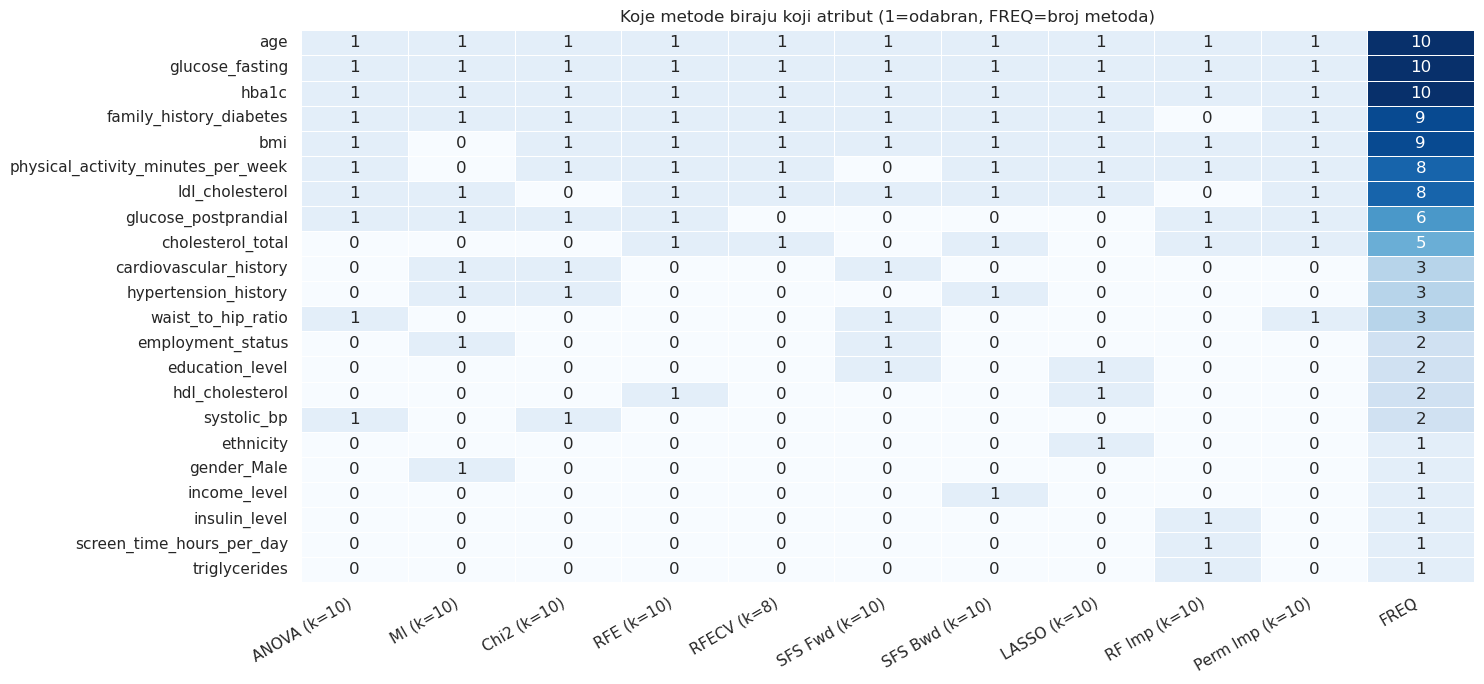

Atributi odabrani od strane najviše metoda: ['age', 'glucose_fasting', 'hba1c', 'family_history_diabetes', 'bmi']


In [147]:
method_features = {
    f'ANOVA (k={N_SELECT})':   selected_anova,
    f'MI (k={N_SELECT})':      selected_mi,
    f'Chi2 (k={N_SELECT})':    selected_chi2,
    f'RFE (k={N_SELECT})':     selected_rfe,
    f'RFECV (k={rfecv.n_features_})': selected_rfecv,
    f'SFS Fwd (k={N_SELECT})': selected_fwd,
    f'SFS Bwd (k={N_SELECT})': selected_bwd,
    f'LASSO (k={len(selected_lasso_k)})': selected_lasso_k,
    f'RF Imp (k={N_SELECT})':  top_k_rf,
    f'Perm Imp (k={N_SELECT})':top_k_perm,
}

all_feats = sorted(set(f for feats in method_features.values() for f in feats))
heatmap_data = pd.DataFrame(
    {method: [1 if f in feats else 0 for f in all_feats]
     for method, feats in method_features.items()},
    index=all_feats
)

# Add frequency column
heatmap_data['FREQ'] = heatmap_data.sum(axis=1)
heatmap_data = heatmap_data.sort_values('FREQ', ascending=False)

plt.figure(figsize=(15, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar=False)
plt.title('Koje metode biraju koji atribut (1=odabran, FREQ=broj metoda)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

most_common = heatmap_data['FREQ'].head(5).index.tolist()
print(f"Atributi odabrani od strane najviše metoda: {most_common}")

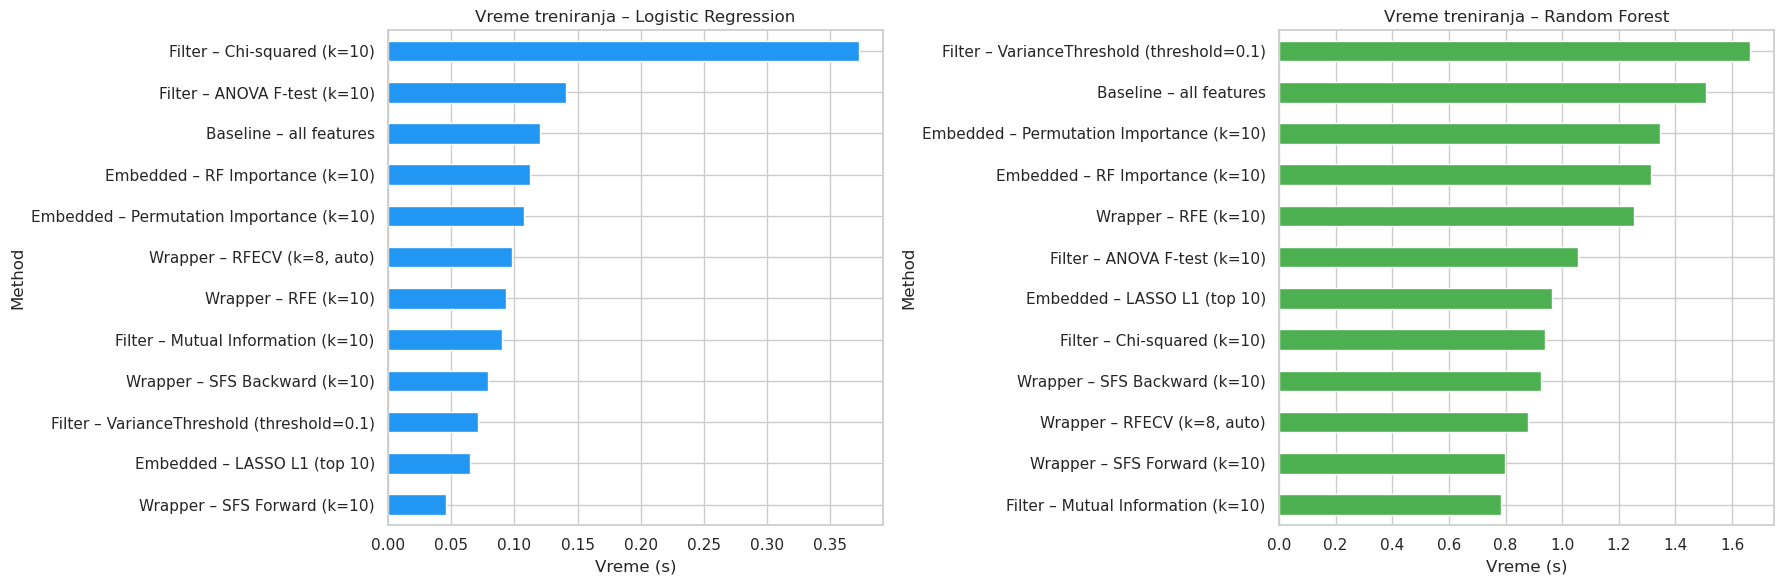

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (label, df_algo, color) in zip(axes, [
    ('Logistic Regression', df_lr, '#2196F3'),
    ('Random Forest',       df_rf, '#4CAF50'),
]):
    td = df_algo.set_index('Method')['Train time (s)'].sort_values()
    td.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'Vreme treniranja – {label}')
    ax.set_xlabel('Vreme (s)')

plt.tight_layout()
plt.show()

## 9. Zaključak

Na skupu podataka o dijabetesu (100 000 uzoraka, 29 atributa) primenjene su sve tri grupe metoda
za selekciju atributa.

**Poređenje metoda:**

| Kategorija | Prednosti | Mane |
|------------|-----------|------|
| **Filter** | Brzo, skalabilno, bez treniranja modela | Ne uzima u obzir interakcije atributa |
| **Wrapper** | Optimizuje za konkretan model, uzima interakcije | Računarski skupo, sporije |
| **Embedded** | Efikasno (jedan trening), uzima model u obzir | Vezano za specifičan algoritam |
